<a href="https://colab.research.google.com/github/24x01a05r9-spec/Iris-classification-project/blob/main/image_classifier_resnet18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device: cpu


100%|██████████| 170M/170M [00:03<00:00, 53.6MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 102MB/s]


Epoch: 1
Loss: 771.2884947657585
Accuracy: 66.486
Epoch: 2
Loss: 533.1703729331493
Accuracy: 77.142
Epoch: 3
Loss: 453.96211925148964
Accuracy: 80.534
Test Accuracy: 78.78


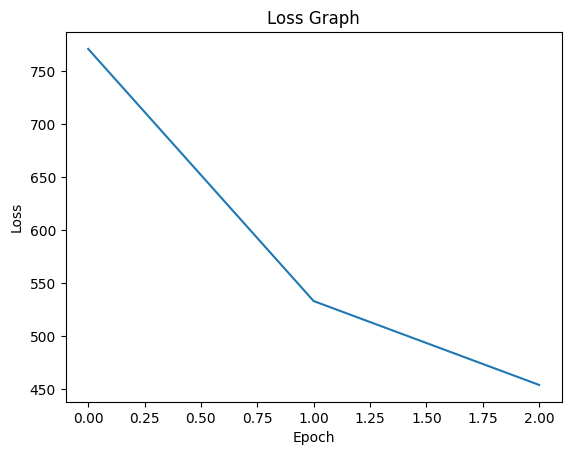

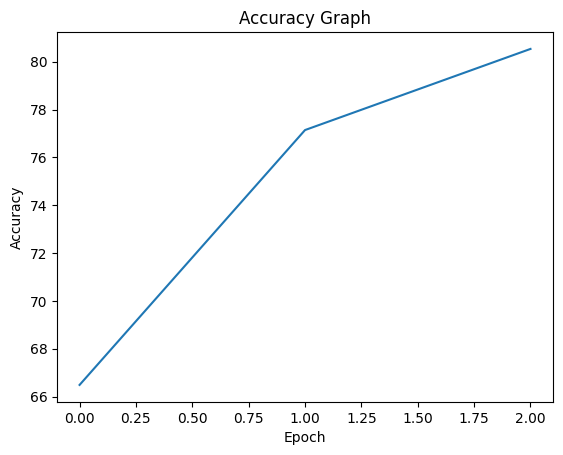

Model Saved


In [1]:
# Simple Deep Learning Project
# CIFAR-10 Image Classification using PyTorch

# Install libraries
!pip install torch torchvision matplotlib -q

# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

# Data augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.ToTensor()
])

# Load dataset
train_data = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_data = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

# Data loader
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# Load pretrained model
model = models.resnet18(pretrained=True)

# Change output layer
model.fc = nn.Linear(model.fc.in_features, 10)

model = model.to(device)

# Loss and optimizer
loss_function = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training
loss_list = []
accuracy_list = []

epochs = 3

for epoch in range(epochs):

    model.train()

    correct = 0
    total = 0
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_function(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    loss_list.append(running_loss)
    accuracy_list.append(accuracy)

    print("Epoch:", epoch + 1)
    print("Loss:", running_loss)
    print("Accuracy:", accuracy)

# Testing
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print("Test Accuracy:", test_accuracy)

# Plot Loss Graph
plt.plot(loss_list)

plt.title("Loss Graph")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

# Plot Accuracy Graph
plt.plot(accuracy_list)

plt.title("Accuracy Graph")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

# Save model
torch.save(model.state_dict(), "model.pth")

print("Model Saved")